# Can sentiment models read Dante?

**Question.** Before building the sentiment level of the project, check whether off-the-shelf Italian classifiers give a signal that makes sense on the *Commedia*. They are trained on modern Italian tweets, not on 14th-century verse, so this is not obvious.

**Sanity check.** The poem has a well-known emotional arc: Hell → Purgatory → Paradise. A model worth using should find the *Inferno* more negative than the *Purgatorio*, and the *Purgatorio* more negative than the *Paradiso*.

**Setup.**
- Unit of analysis: the **tercet** (4,811 in total), since a single verse is often too short to carry an emotion.
- Models: [`feel-it-italian-sentiment`](https://huggingface.co/MilaNLProc/feel-it-italian-sentiment) (positive / negative) and [`feel-it-italian-emotion`](https://huggingface.co/MilaNLProc/feel-it-italian-emotion) (anger, fear, joy, sadness).
- We keep the raw **logits** instead of probabilities: the probabilities are saturated at 0 or 1, while logits still rank tercets. *Valence* = logit(positive) − logit(negative); above 0 means the model predicts "positive".

Scoring all tercets takes about 4 minutes per model on a CPU; results are cached in `data/sentiment/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from divina_midi.corpus import load_corpus
from divina_midi.features import sentiment

DATA = Path("..") / "data"
corpus = load_corpus(DATA / "commedia.csv", download=False)
sent = sentiment.tercet_features(corpus, "feel-it-sentiment", cache_dir=DATA / "sentiment")
emo = sentiment.tercet_features(corpus, "feel-it-emotion", cache_dir=DATA / "sentiment")

CANTICHE = ["Inferno", "Purgatorio", "Paradiso"]
COLORS = {"Inferno": "#2a78d6", "Purgatorio": "#eb6834", "Paradiso": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
})
len(sent), len(emo)

(4811, 4811)

## 1. Does valence follow the arc of the poem?

In [2]:
def summary(df, column):
    g = df.groupby("cantica")[column]
    out = pd.DataFrame({"mean": g.mean(), "95% CI ±": 1.96 * g.sem(),
                        "share > 0": g.apply(lambda v: (v > 0).mean())})
    return out.loc[CANTICHE].round(2)

summary(sent, "valence")

,mean,95% CI ±,share > 0
cantica,,,
Inferno,-5.29,0.26,0.17
Purgatorio,-3.46,0.32,0.29
Paradiso,-1.29,0.35,0.42


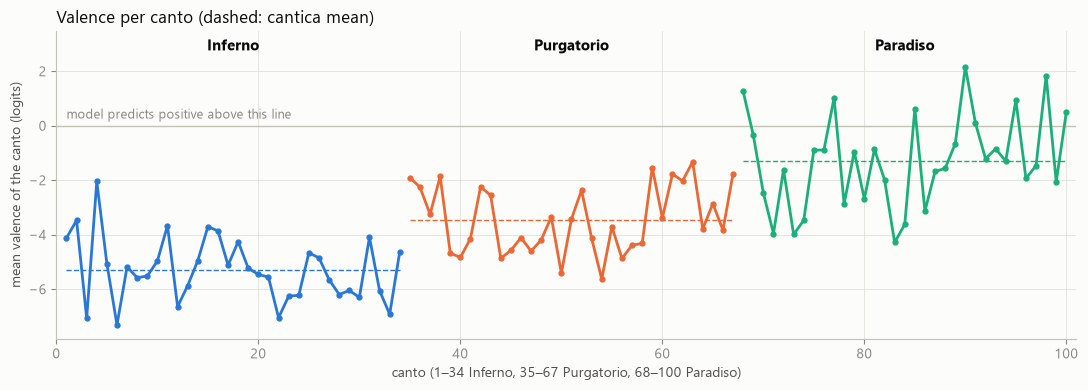

In [3]:
by_canto = sent.groupby(["cantica", "canto"], sort=False)["valence"].mean().reset_index()
by_canto["position"] = np.arange(1, len(by_canto) + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0, color="#c3c2b7", linewidth=1)
for cantica in CANTICHE:
    part = by_canto[by_canto.cantica == cantica]
    ax.plot(part.position, part.valence, color=COLORS[cantica], linewidth=2, marker="o", markersize=3.5)
    ax.text(part.position.mean(), by_canto.valence.max() + 0.6, cantica, ha="center",
            color=INK, fontsize=11, fontweight="bold")
    ax.hlines(part.valence.mean(), part.position.min(), part.position.max(),
              color=COLORS[cantica], linewidth=1, linestyle="--")
ax.set_xlim(0, 101)
ax.set_ylim(by_canto.valence.min() - 0.5, by_canto.valence.max() + 1.3)
ax.set_xlabel("canto (1–34 Inferno, 35–67 Purgatorio, 68–100 Paradiso)")
ax.set_ylabel("mean valence of the canto (logits)")
ax.set_title("Valence per canto (dashed: cantica mean)", loc="left", fontsize=12)
ax.text(1, 0.15, "model predicts positive above this line", ha="left", va="bottom", color=MUTED, fontsize=9)
plt.tight_layout()

## 2. Which emotions does the model see?

Share of tercets whose top emotion is each label.

col_0,anger,fear,sadness,joy
cantica,,,,
Inferno,0.332,0.068,0.399,0.201
Purgatorio,0.234,0.044,0.396,0.325
Paradiso,0.232,0.023,0.241,0.504


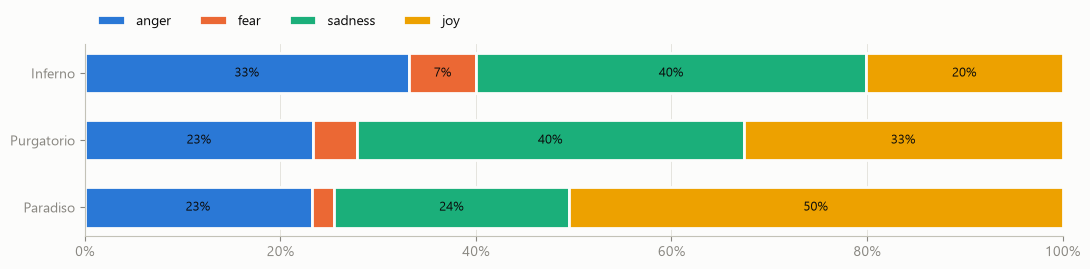

In [4]:
EMOTIONS = ["anger", "fear", "sadness", "joy"]
EMO_COLORS = dict(zip(EMOTIONS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
top = emo[EMOTIONS].idxmax(axis=1)
shares = pd.crosstab(emo.cantica, top, normalize="index").loc[CANTICHE, EMOTIONS]

fig, ax = plt.subplots(figsize=(11, 2.8))
left = np.zeros(len(shares))
for emotion in EMOTIONS:
    values = shares[emotion].to_numpy()
    ax.barh(CANTICHE, values, left=left, color=EMO_COLORS[emotion], edgecolor="#fcfcfb",
            linewidth=2, height=0.6, label=emotion)
    for y, (x, v) in enumerate(zip(left, values)):
        if v >= 0.06:
            ax.text(x + v / 2, y, f"{v:.0%}", ha="center", va="center", color=INK, fontsize=9)
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
ax.legend(ncol=4, loc="lower left", bbox_to_anchor=(0, 1.02), frameon=False)
plt.tight_layout()
shares.round(3)

## 3. Read the extremes

Numbers can hide nonsense. The most negative and most positive tercets of each cantica, according to the sentiment model:

In [5]:
pd.set_option("display.max_colwidth", 200)
rows = []
for cantica in CANTICHE:
    part = sent[sent.cantica == cantica].sort_values("valence")
    rows += [part.head(3).assign(extreme="most negative"), part.tail(3).assign(extreme="most positive")]
pd.concat(rows)[["extreme", "cantica", "canto", "line", "valence", "text"]].round(2)

,extreme,cantica,canto,line,valence,text
1247,most negative,Inferno,27,115,-8.52,"Venir se ne dee giù tra ' miei meschini perché diede 'l consiglio frodolente, dal quale in qua stato li sono a' crini;"
1392,most negative,Inferno,30,127,-8.52,"tu hai l'arsura e 'l capo che ti duole, e per leccar lo specchio di Narcisso, non vorresti a 'nvitar molte parole""."
1263,most negative,Inferno,28,25,-8.52,Tra le gambe pendevan le minugia; la corata pareva e 'l tristo sacco che merda fa di quel che si trangugia.
816,most positive,Inferno,18,121,8.38,"già t' ho veduto coi capelli asciutti, e se' Alessio Interminei da Lucca: però t'adocchio più che li altri tutti""."
1187,most positive,Inferno,26,79,8.40,"""O voi che siete due dentro ad un foco, s'io meritai di voi mentre ch'io vissi, s'io meritai di voi assai o poco"
727,most positive,Inferno,16,130,8.42,"ch'i' vidi per quell' aere grosso e scuro venir notando una figura in suso, maravigliosa ad ogne cor sicuro,"
2247,most negative,Purgatorio,14,97,-8.52,Ov'è 'l buon Lizio e Arrigo Mainardi? Pier Traversaro e Guido di Carpigna? Oh Romagnuoli tornati in bastardi!
2830,most negative,Purgatorio,26,85,-8.52,"in obbrobrio di noi, per noi si legge, quando partinci, il nome di colei che s'imbestiò ne le 'mbestiate schegge."
2229,most negative,Purgatorio,14,43,-8.52,"Tra brutti porci, più degni di galle che d'altro cibo fatto in uman uso, dirizza prima il suo povero calle."
3109,most positive,Purgatorio,32,28,8.41,La bella donna che mi trasse al varco e Stazio e io seguitavam la rota che fé l'orbita sua con minore arco.


Some famous passages, to check against intuition (addressed by the line that opens the tercet):

In [6]:
famous = {
    ("Inferno", 1, 1): "Nel mezzo del cammin...",
    ("Inferno", 3, 1): "Per me si va ne la città dolente",
    ("Inferno", 5, 103): "Amor, ch'a nullo amato amar perdona (Francesca)",
    ("Inferno", 33, 73): "Poscia, più che 'l dolor, poté 'l digiuno (Ugolino)",
    ("Purgatorio", 1, 1): "Per correr miglior acque...",
    ("Paradiso", 33, 1): "Vergine Madre, figlia del tuo figlio",
    ("Paradiso", 33, 145): "l'amor che move il sole e l'altre stelle",
}
both = sent.merge(emo[["cantica", "canto", "tercet"] + EMOTIONS], on=["cantica", "canto", "tercet"])
picked = pd.concat([both[(both.cantica == c) & (both.canto == n) & (both.line <= l)].tail(1)
                    for c, n, l in famous])
picked.insert(0, "passage", list(famous.values()))
picked["top emotion"] = picked[EMOTIONS].idxmax(axis=1)
picked[["passage", "valence", "top emotion", "text"]].round(2)

,passage,valence,top emotion,text
0,Nel mezzo del cammin...,-8.22,sadness,"Nel mezzo del cammin di nostra vita mi ritrovai per una selva oscura, ché la diritta via era smarrita."
94,Per me si va ne la città dolente,-8.42,sadness,"'Per me si va ne la città dolente, per me si va ne l'etterno dolore, per me si va tra la perduta gente."
225,"Amor, ch'a nullo amato amar perdona (Francesca)",7.41,joy,"Amor, ch'a nullo amato amar perdona, mi prese del costui piacer sì forte, che, come vedi, ancor non m'abbandona."
1520,"Poscia, più che 'l dolor, poté 'l digiuno (Ugolino)",-8.42,sadness,"già cieco, a brancolar sovra ciascuno, e due dì li chiamai, poi che fur morti. Poscia, più che 'l dolor, poté 'l digiuno""."
1596,Per correr miglior acque...,-7.72,joy,"Per correr miglior acque alza le vele omai la navicella del mio ingegno, che lascia dietro a sé mar sì crudele;"
4762,"Vergine Madre, figlia del tuo figlio",8.36,joy,"""Vergine Madre, figlia del tuo figlio, umile e alta più che creatura, termine fisso d'etterno consiglio,"
4810,l'amor che move il sole e l'altre stelle,8.29,joy,l'amor che move il sole e l'altre stelle.


## Findings

**The arc is there.** Mean valence rises from −5.3 (Inferno) to −3.5 (Purgatorio) to −1.3 (Paradiso), with non-overlapping confidence intervals; the share of tercets read as positive goes 17% → 29% → 42%, and *joy* as top emotion 20% → 33% → 50%. *Anger* is highest in the Inferno (33%).

**The model is biased towards negative.** Even the Paradiso averages below zero: Dante's language reads as gloomy to a model trained on modern tweets. So the absolute threshold (0) is not meaningful, but the **relative** position of a tercet within the whole poem is. This fits the mapping, which already rescales every feature on percentiles of the whole poem.

**It reads words, not irony.** The most negative tercets of the Paradiso are Dante's invectives against corrupt clergy and Florentine families: a correct reading. The extremes of the Inferno are mostly right too (graphic descriptions of punishment), but some "most positive" Inferno tercets are polite addresses or words like *maravigliosa* in a grim context. Among the famous passages, 6 of 7 match intuition; *Per correr miglior acque* comes out negative because of *mar sì crudele*.

**Scores are close to binary per tercet.** Logits saturate around ±8.5, so a single tercet is mostly "very negative" or "very positive". Averages over a few tercets or a canto are much smoother than individual scores.

**Fear is almost never predicted** (2–7%), even in the Inferno: the emotion model is reliable for joy / sadness / anger, much less for fear.

**A single tercet is ambiguous even for a human reader.** We considered validating the model against human labels on random tercets, but out of context many tercets have no clear emotional tone: a description of a landscape, a line of dialogue, a list of names. Agreement on isolated tercets would measure that ambiguity more than the model's quality. The emotional arc lives at a larger scale, across groups of tercets and whole cantos, which is where the checks above were made.

### Verdict

Usable for the sentiment level, with two design choices:
1. map **relative** valence (percentiles over the whole poem), never the raw sign;
2. **smooth** over neighbouring tercets (a moving average), so the music follows the emotional arc instead of reacting to each tercet on its own.